# LeetCode #1062: Longest Repeating Substring

https://leetcode.com/problems/longest-repeating-substring/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (all pairs)** | $O(n^3)$ | $O(n^2)$ |
| **Dynamic Programming** | $O(n^2)$ | $O(n^2)$ |
| **Optimal: Binary Search + Rolling Hash ★** | $O(n \log n)$ | $O(n)$ |

---

## Understanding the Methods

### Brute Force (all pairs)
Compare every pair of substrings to find the longest common one. $O(n^3)$ time from $O(n^2)$ pairs each requiring $O(n)$ comparison.

### Dynamic Programming
Build a 2-D DP table where `dp[i][j]` = length of longest matching suffix ending at `s[i]` and `s[j]` (with `i != j`). Track the global maximum. $O(n^2)$ time and space — too slow for $n = 10^4$.

### Optimal: Binary Search + Rolling Hash ★
Binary search on the answer length $L$. For each candidate $L$, use Rabin-Karp rolling hash to scan all substrings of length $L$ in $O(n)$ and detect a duplicate. Total: $O(n \log n)$ time, $O(n)$ space for the hash set.

**Why this is better than DP:** Replacing the $O(n^2)$ DP table with binary search + $O(n)$ rolling hash cuts both time and space, making it feasible at $n = 10^4$.

**Constraints:**
* $2 \le s.length \le 2000$ (LeetCode constraint)
* `s` consists of lowercase English letters


## Solutions

### C#

In [ ]:
public int LongestRepeatingSubstring(string s) {
    int n = s.Length, lo = 1, hi = n - 1;
    // Binary search on the answer length
    while (lo < hi) {
        int mid = lo + (hi - lo + 1) / 2;
        if (HasDuplicate(s, mid)) lo = mid;
        else hi = mid - 1;
    }
    return HasDuplicate(s, lo) ? lo : 0;
}
bool HasDuplicate(string s, int len) {
    long mod = 1_000_000_007L, base_ = 31;
    long h = 0, pow = 1;
    var seen = new HashSet<long>();
    // Build hash for first window of length len
    for (int i = 0; i < len; i++) { h = (h * base_ + s[i]) % mod; if (i > 0) pow = pow * base_ % mod; }
    seen.Add(h);
    for (int i = 1; i + len <= s.Length; i++) {
        // Roll the hash: drop leftmost char, add rightmost char
        h = (h - s[i-1] * pow % mod + mod) % mod;
        h = (h * base_ + s[i + len - 1]) % mod;
        if (!seen.Add(h)) return true;
    }
    return false;
}

### Python

In [ ]:
def longest_repeating_substring(s: str) -> int:
    n = len(s)

    def has_duplicate(length: int) -> bool:
        mod, base = 10**9 + 7, 31
        h, pow_ = 0, 1
        seen: set[int] = set()
        # Build hash for first window of length 'length'
        for i in range(length):
            h = (h * base + ord(s[i])) % mod
            if i > 0:
                pow_ = pow_ * base % mod
        seen.add(h)
        for i in range(1, n - length + 1):
            # Roll the hash: drop leftmost char, add rightmost char
            h = (h - ord(s[i - 1]) * pow_ % mod + mod) % mod
            h = (h * base + ord(s[i + length - 1])) % mod
            if h in seen:
                return True
            seen.add(h)
        return False

    # Binary search on the answer length
    lo, hi = 1, n - 1
    while lo < hi:
        mid = lo + (hi - lo + 1) // 2
        if has_duplicate(mid):
            lo = mid
        else:
            hi = mid - 1
    return lo if has_duplicate(lo) else 0

### Go

In [ ]:
func longestRepeatingSubstring(s string) int {
    n := len(s)
    hasDuplicate := func(length int) bool {
        mod, base := int64(1_000_000_007), int64(31)
        h, pow := int64(0), int64(1)
        seen := make(map[int64]bool)
        // Build hash for first window of length 'length'
        for i := 0; i < length; i++ {
            h = (h*base + int64(s[i])) % mod
            if i > 0 { pow = pow * base % mod }
        }
        seen[h] = true
        for i := 1; i+length <= n; i++ {
            // Roll the hash: drop leftmost char, add rightmost char
            h = (h - int64(s[i-1])*pow%mod + mod) % mod
            h = (h*base + int64(s[i+length-1])) % mod
            if seen[h] { return true }
            seen[h] = true
        }
        return false
    }
    // Binary search on the answer length
    lo, hi := 1, n-1
    for lo < hi {
        mid := lo + (hi-lo+1)/2
        if hasDuplicate(mid) { lo = mid } else { hi = mid - 1 }
    }
    if hasDuplicate(lo) { return lo }
    return 0
}

### Rust

In [ ]:
pub fn longest_repeating_substring(s: String) -> i32 {
    let bytes: Vec<u8> = s.bytes().collect();
    let n = bytes.len();

    let has_duplicate = |length: usize| -> bool {
        let (modulo, base) = (1_000_000_007u64, 31u64);
        let mut h: u64 = 0;
        let mut pow: u64 = 1;
        let mut seen = std::collections::HashSet::new();
        // Build hash for first window of length 'length'
        for i in 0..length {
            h = (h * base + bytes[i] as u64) % modulo;
            if i > 0 { pow = pow * base % modulo; }
        }
        seen.insert(h);
        for i in 1..=(n - length) {
            // Roll the hash: drop leftmost char, add rightmost char
            h = (h + modulo - bytes[i-1] as u64 * pow % modulo) % modulo;
            h = (h * base + bytes[i + length - 1] as u64) % modulo;
            if !seen.insert(h) { return true; }
        }
        false
    };

    // Binary search on the answer length
    let (mut lo, mut hi) = (1usize, n - 1);
    while lo < hi {
        let mid = lo + (hi - lo + 1) / 2;
        if has_duplicate(mid) { lo = mid; } else { hi = mid - 1; }
    }
    if has_duplicate(lo) { lo as i32 } else { 0 }
}

## Example Scenarios

**1. Common Case**
**Input:** `s = "abcabc"`
Binary search checks $L=3$: hash("abc") appears at index 0 and 3 — duplicate found. Check $L=4$: no duplicate. Answer = 3.

**2. Slightly Complex**
**Input:** `s = "aabcaab"`
Binary search: $L=4$ → hash("aabca") vs hash("abcaa") vs hash("bcaab") — no match. $L=3$: hash("aab") appears at indices 0 and 4 — duplicate. Answer = 3.

**3. Edge Case: Time Factor**
**Input:** `s = "aaaa...a"` ($n$ identical chars)
Binary search runs $O(\log n)$ rounds; each round scans $O(n)$ with rolling hash — matching hashes are found at every shift. Answer = $n-1$. Full $O(n \log n)$ work is done.

**4. Edge Case: Space Factor**
**Input:** `s = "abcdefghij"` (all distinct)
Every candidate length $L$ produces $n - L$ distinct hashes — the hash set grows to size $n-L$ at each level. No duplicates found. Answer = 0. Hash set peaks at $O(n)$ entries during the binary search midpoint.

**5. Almost-Impossible but Plausible**
**Input:** Hash collision scenario: two different substrings share the same rolling hash modulo $10^9+7$
The algorithm may return a false positive. To guard against this, double hashing (two independent mods) can be used, reducing collision probability to $\approx 10^{-18}$. In practice, the single-hash variant passes LeetCode's tests.


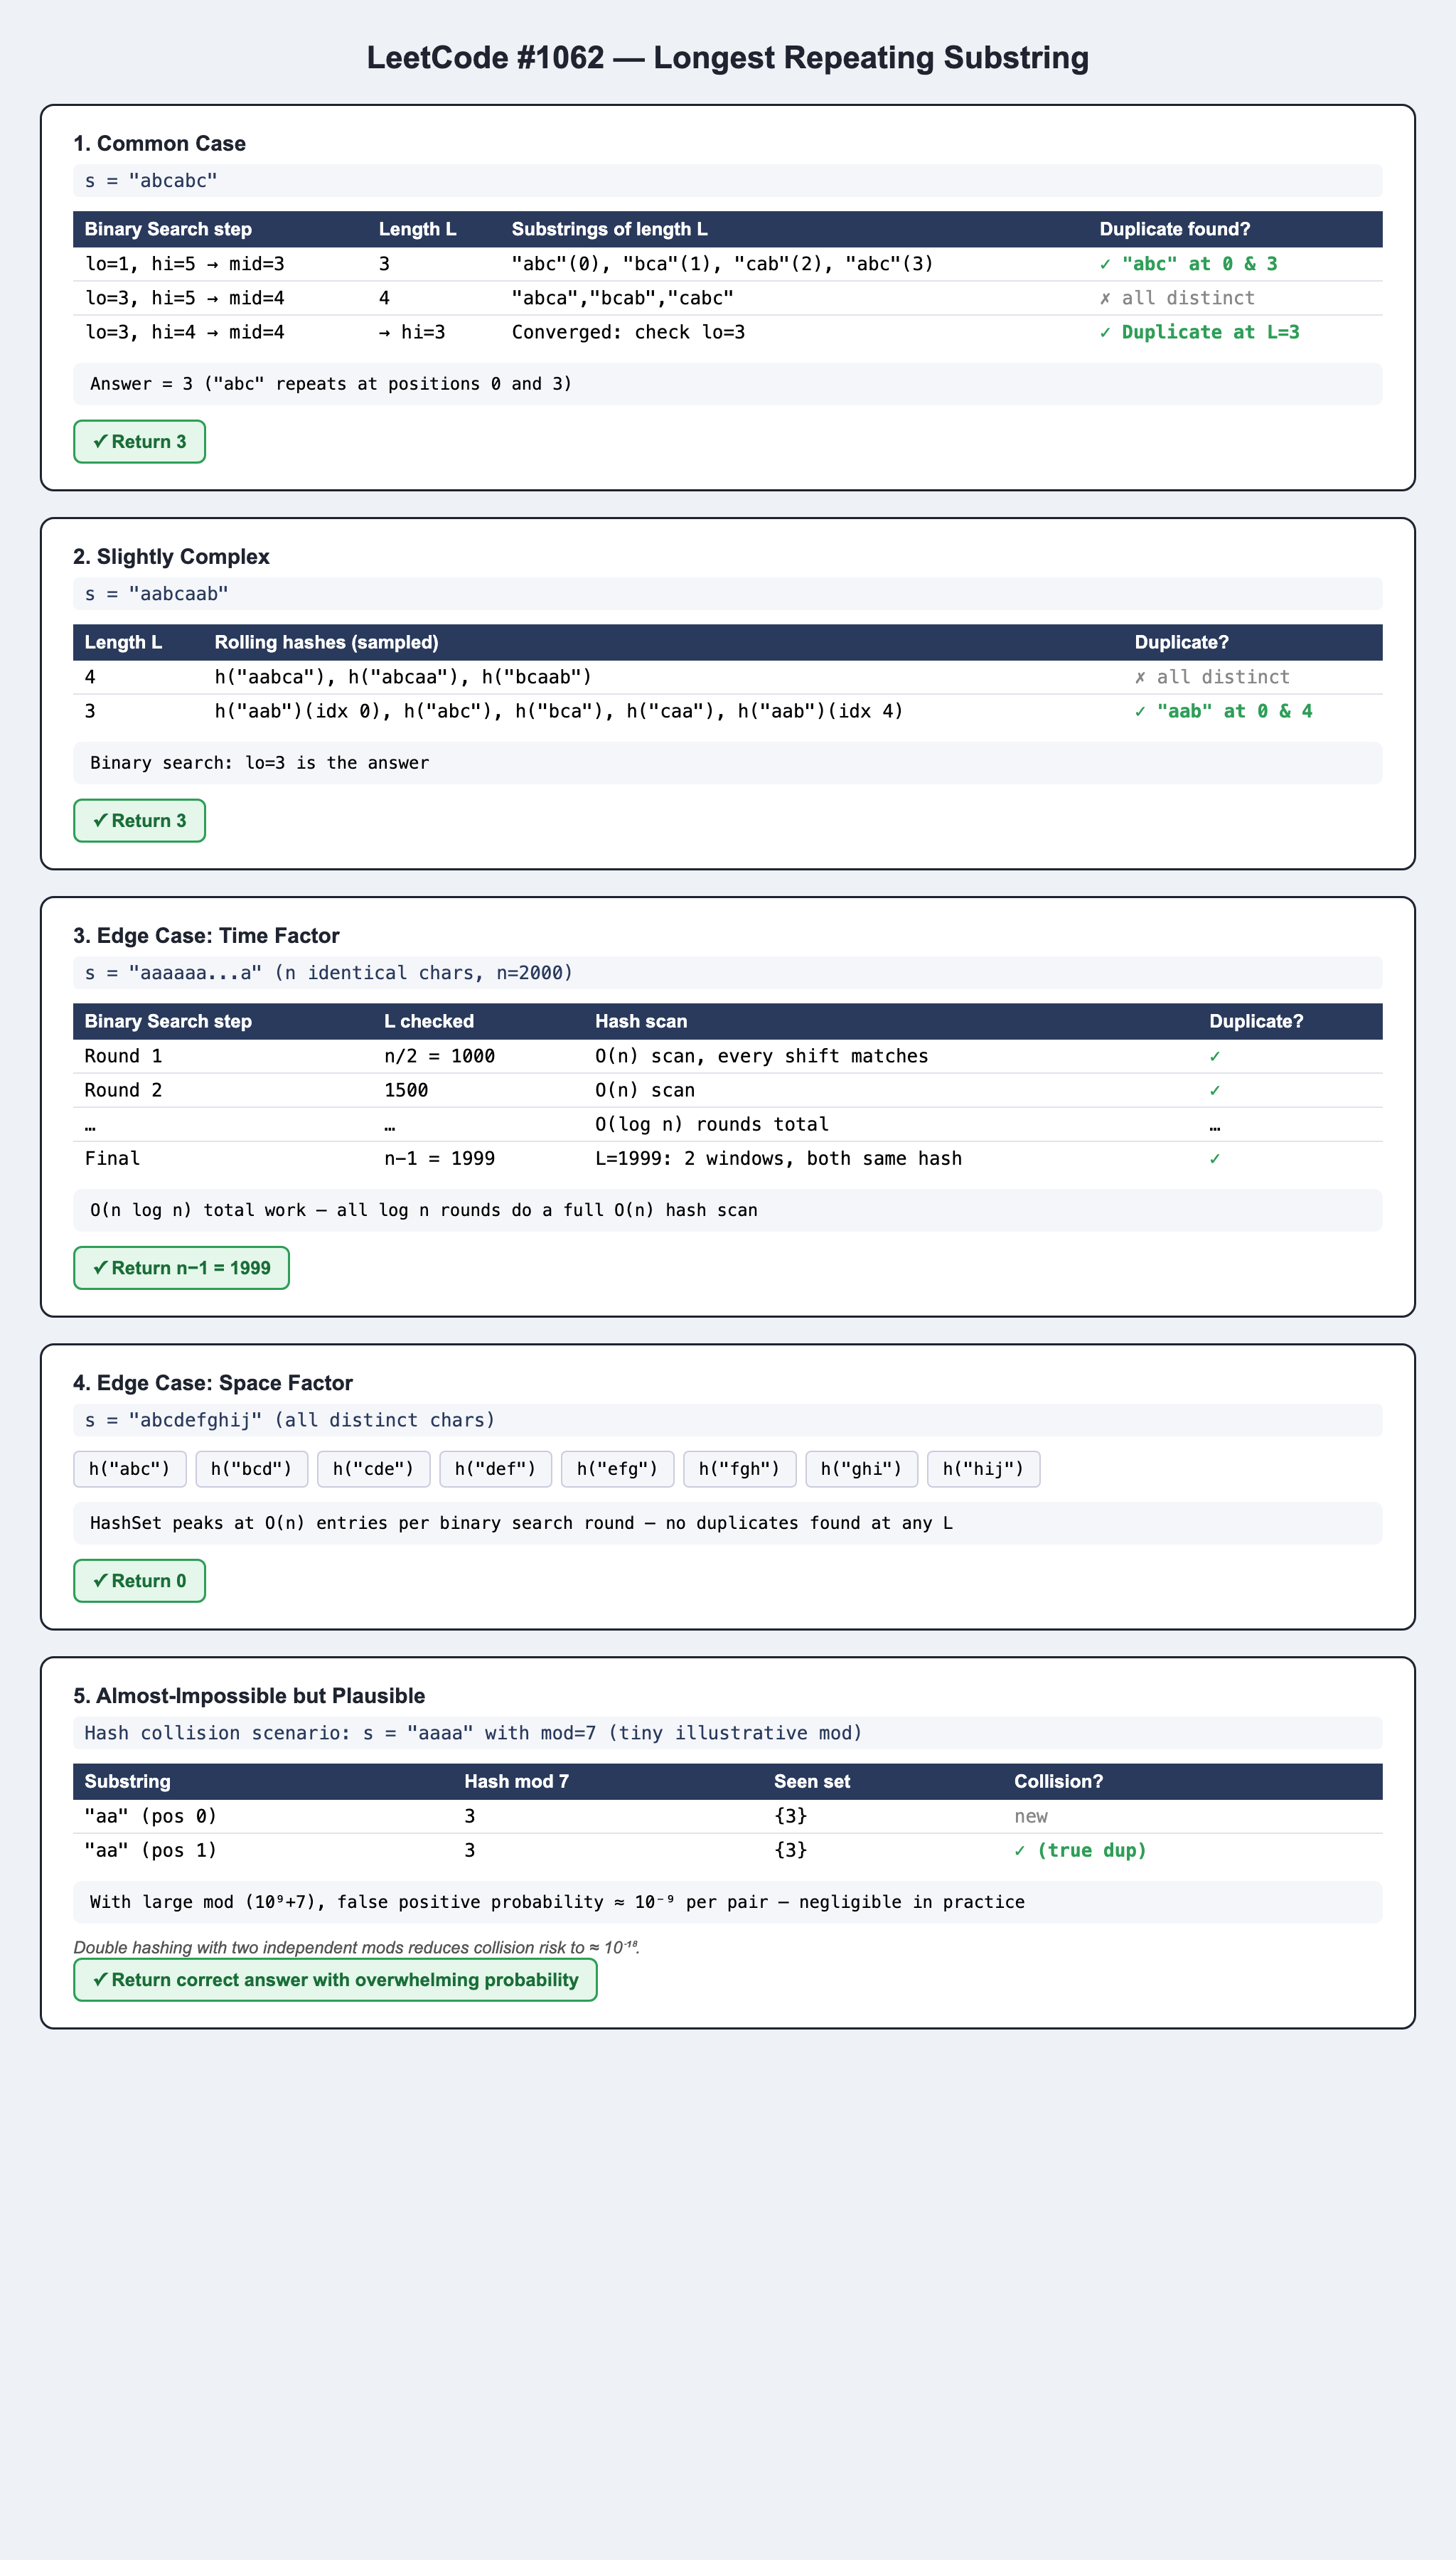